In [32]:
!pip  install konlpy JPype1
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
!pip install mecab-python3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 44.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]
Installing automake (A dependency for mecab-ko)
Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  autoconf autotools-dev m4
Suggested packages:
  autoconf-archive gnu-standards autoconf-doc libtool gettext m4-doc
The following NEW packages will be installed:
  autoconf automake autotools-dev m4
0 upgraded, 4 newly installed, 0 to remove and 144 not upgraded.
Need to get 1186 kB of a

In [38]:
!pip install hanja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 6.0.2
    Uninstalling PyYAML-6.0.2:
      Successfully uninstalled PyYAML-6.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [hanja]m12/13 [hanja]]e]


In [1]:
import os
import re
import urllib.request
import zipfile
import pandas as pd
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

import hanja
import konlpy
from konlpy.tag import Mecab
import sentencepiece as spm


logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

설정된 폰트: NanumBarunGothic
2.7.1+cu118


In [3]:
base_path = os.path.join(os.getenv("HOME"), "work")
project_path = os.path.join(base_path, "AIFFEL_quest_rs")

dataset_path = os.path.join(base_path, "attention", "data")

In [31]:
vocab_size = 3000
PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3


def preprocess_korean(text):
    """
    한국어 문장 전처리 함수
    1. 한자를 한글로 변환 (예: 城市 -> 성시)
    2. 쉼표(,) 및 필수 문장부호 앞뒤 공백 추가 (토큰화 대비)
    3. 한글, 영어, 숫자, 주요 문장부호만 남기고 정제
    4. Mecab을 이용한 토큰화 후 공백으로 연결
    """
    if not isinstance(text, str):
        return ""
    
    # 1. 한자 -> 한글 변환
    text = hanja.translate(text, 'substitution')
    
    # 2. 쉼표 및 문장부호 분리 (부호 앞뒤로 공백 삽입)
    text = re.sub(r"([.,!?¿])", r" \1 ", text)
    
    # 3. 한글, 영문, 숫자, 지정된 특수문자 외 제거
    text = re.sub(r"[^가-힣a-zA-Z0-9.,!?¿\s]", "", text)
    
    # 4. Mecab 토큰화 (형태소 단위 분리)
    tokens = Mecab().morphs(text)
    
    # 연속된 공백 제거 및 양끝 공백 정리
    cleaned_text = " ".join(tokens).strip()
    return cleaned_text


def preprocess_english(text):
    """
    영어 문장 전처리 함수
    1. 소문자 변환
    2. 쉼표(,) 및 필수 문장부호 앞뒤 공백 추가
    3. 영문, 숫자, 주요 문장부호만 남기고 정제
    """
    if not isinstance(text, str):
        return ""
    
    # 1. 소문자화
    text = text.lower()
    
    # 2. 쉼표 및 문장부호 분리
    text = re.sub(r"([.,!?¿])", r" \1 ", text)
    
    # 3. 영문, 숫자, 지정된 특수문자 외 제거
    text = re.sub(r"[^a-zA-Z0-9.,!?¿\s]", "", text)
    
    # 연속된 공백 제거 및 양끝 공백 정리
    cleaned_text = " ".join(text.split()).strip()
    return cleaned_text

def load_and_preprocess_dataset(ko_path, en_path):
    """
    줄 번호가 매칭된 한국어/영어 txt 파일을 불러와 DataFrame으로 매칭하고
    결측치 처리, 중복 제거, 전처리를 수행하는 함수
    """
    print("1. 파일 로드 중...")
    with open(ko_path, "r", encoding="utf-8") as f:
        ko_lines = [line.strip() for line in f.readlines()]
        
    with open(en_path, "r", encoding="utf-8") as f:
        en_lines = [line.strip() for line in f.readlines()]
        
    # 두 파일의 라인 수가 맞는지 확인
    if len(ko_lines) != len(en_lines):
        print(f"⚠️ 경고: 파일의 줄 수가 일치하지 않습니다! (KO: {len(ko_lines)}, EN: {len(en_lines)})")
        # 최소 라인 수에 맞춰 슬라이싱 (보수적 처리)
        min_len = min(len(ko_lines), len(en_lines))
        ko_lines = ko_lines[:min_len]
        en_lines = en_lines[:min_len]

    # DataFrame 생성
    df = pd.DataFrame({
        "korean": ko_lines,
        "english": en_lines
    })
    
    total_raw = len(df)
    print(f"총 로드된 데이터: {total_raw}개")
    
    # 2. 결측치(NaN) 제거
    df.dropna(subset=["korean", "english"], inplace=True)
    
    # 3. 전처리 전 완전 중복 데이터 제거 (Source와 Target 쌍이 모두 같은 경우)
    df.drop_duplicates(subset=["korean", "english"], inplace=True)
    
    # 4. 한국어 및 영어 개별 전처리 적용
    print("2. 문장 전처리 및 토큰화 진행 중 (시간이 다소 소요될 수 있습니다)...")
    df["korean_clean"] = df["korean"].apply(preprocess_korean)
    df["english_clean"] = df["english"].apply(preprocess_english)
    
    # 5. 전처리 후 빈 문자열이 된 데이터 처리 (공백만 남은 문장 등)
    # 빈 칸을 NaN으로 만들어서 dropna로 날려버립니다.
    df["korean_clean"].replace("", None, inplace=True)
    df["english_clean"].replace("", None, inplace=True)
    df.dropna(subset=["korean_clean", "english_clean"], inplace=True)
    
    # 6. 전처리 후 발생한 중복 데이터 추가 제거 (예: 특수문자만 달라졌던 문장들)
    df.drop_duplicates(subset=["korean_clean"], inplace=True)
    df.drop_duplicates(subset=["english_clean"], inplace=True)
    
    print("\n--- 전처리 완료 통계 ---")
    print(f"원본 데이터 수: {total_raw}")
    print(f"정제 후 데이터 수: {len(df)}")
    print(f"제거된 데이터 수: {total_raw - len(df)}")
    print("------------------------")
    
    return df.reset_index(drop=True)

def make_english_spm(cleaned_df, target_col_name):
    print("2. 영어 전체 데이터를 활용하여 SentencePiece(SPM) 학습 중...")
    
    # 중복이 제거된 전체 영어 문장을 SPM 학습용 임시 파일로 저장
    temp_corpus_path = "eng_raw_corpus.txt"
    with open(temp_corpus_path, "w", encoding="utf-8") as f:
        for line in cleaned_df[target_col_name]:
            f.write(line + "\n")

    # SPM 학습 (BOS, EOS, PAD, UNK 토큰 ID 고정)
    spm.SentencePieceTrainer.train(
        input = temp_corpus_path,
        model_prefix = "decoder_eng_spm",
        vocab_size = vocab_size,
        pad_id = PAD_ID, bos_id = BOS_ID, eos_id = EOS_ID, unk_id = UNK_ID
    )
    
    decoder_tokenizer = spm.SentencePieceProcessor()
    decoder_tokenizer.load("decoder_eng_spm.model")

    # 임시 파일 삭제 (깔끔한 환경 유지)
    if os.path.exists(temp_corpus_path):
        os.remove(temp_corpus_path)

    return decoder_tokenizer

def make_ko_vocab(cleaned_df, target_col_name):
    # 한국어 고유 토큰 빈도수 계산 후 상위 단어 사전 생성
    all_ko_tokens = []
    for sentence in cleaned_df[target_col_name]:
        all_ko_tokens.extend(sentence.split())
    
    vocab_counts = Counter(all_ko_tokens)
    top_ko_tokens = [token for token, _ in vocab_counts.most_common(vocab_size - 4)]
    
    ko_vocab = {"<pad>": PAD_ID, "<bos>": BOS_ID, "<eos>": EOS_ID, "<unk>": UNK_ID}
    for idx, token in enumerate(top_ko_tokens):
        ko_vocab[token] = idx + 4

    return ko_vocab

def encode_korean(text, vocab):
    return [vocab.get(token, vocab["<unk>"]) for token in text.split()]

class TranslationDataset(Dataset):
    def __init__(self, data, ko_vocab, decoder_tokenizer, max_len):
        self.data = data
        self.ko_vocab = ko_vocab
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = PAD_ID
        self.bos_id = BOS_ID
        self.eos_id = EOS_ID

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['korean_clean']
        trg_text = self.data.iloc[idx]['english']
    
        # 1. 인코딩 처리
        src_ids = encode_korean(src_text, self.ko_vocab)
        trg_ids = self.decoder_tokenizer.encode(trg_text)
    
        # 2. 한국어(Encoder 인풋): max_len 크기로 슬라이싱 후 패딩 추가
        src_ids = src_ids[:self.max_len]
        src_ids += [self.pad_id] * (self.max_len - len(src_ids))
    
        # 3. 영어(Decoder 인풋/타겟): BOS/EOS를 고려한 전체 타겟 구성
        # 최대 길이를 맞추기 위해 미리 길이를 제어합니다.
        full_trg = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        
        # 4. 한 칸씩 교차 배치 (Shift)
        # trg_input과 trg_label의 길이는 동일하게 '원래 full_trg 길이 - 1'이 됩니다.
        trg_input = full_trg[:-1]  # [BOS]로 시작, 마지막 [EOS] 제외
        trg_label = full_trg[1:]   # 실제 첫 토큰으로 시작, [EOS]로 끝남
    
        # 5. 디코더 데이터 패딩 추가 (최대 길이는 max_len - 1이 됩니다)
        target_max_len = self.max_len - 1
        trg_input += [self.pad_id] * (target_max_len - len(trg_input))
        trg_label += [self.pad_id] * (target_max_len - len(trg_label))
    
        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

def train_step(model, data_loader, optimizer, criterion, epoch):
    """
    순수하게 1 에포크 동안 모델을 학습시키고 평균 훈련 손실을 반환합니다.
    """
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(src, trg_input)
        
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)


def eval_step(model, data_loader, criterion):
    """
    주어진 데이터로더(Validation 또는 Test)에 대해 손실을 계산해 반환합니다.
    """
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            outputs, _ = model(src, trg_input)
            
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)
            total_loss += loss.item()

    return total_loss / len(data_loader)


def plot_attention(attention, src_tokens, pred_tokens):
    """
    [개선]: 한글 깨짐 방지 폰트 설정 권장 및 차원 연동 안정화
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 12}

    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens, fontdict=fontdict)

    plt.show()

def evaluate(sentence, model, ko_vocab, decoder_tokenizer, max_len=40):
    model.eval()

    # 1. 한국어 전처리 및 인코딩
    cleaned_sentence = preprocess_korean(sentence) 
    src_ids = encode_korean(cleaned_sentence, ko_vocab)[:max_len]
    padding_len = max(0, max_len - len(src_ids))
    src_ids = src_ids + [PAD_ID] * padding_len
    
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        dec_input = torch.tensor([BOS_ID]).to(device) 
        
        pred_ids = []
        attention_list = []

        # 2. Autoregressive 디코딩 루프
        for t in range(max_len):
            output, hidden, attention = model.decoder(dec_input, hidden, encoder_outputs)
            
            top1 = output.argmax(1) 
            pred_id = top1.item()
            
            # [수정]: EOS 토큰 ID 자체도 리스트에 포함시킨 후 루프를 탈출합니다.
            pred_ids.append(pred_id)
            attention_list.append(attention.cpu().numpy())
            
            if pred_id == EOS_ID:
                break
            
            dec_input = top1 

    # 3. 텍스트 복원 및 종료 토큰 문자열 강제 결합
    # SentencePiece의 .decode()는 </s> 토큰을 만나면 자동으로 문자열 변환에서 생략하는 경우가 많습니다.
    # 따라서 가독성을 위해 결과 텍스트 끝에 명시적으로 붙여줍니다.
    if pred_ids and pred_ids[-1] == EOS_ID:
        # EOS를 제외한 실제 문장을 먼저 복원한 뒤 뒤에 붙여줍니다.
        main_text = decoder_tokenizer.decode(pred_ids[:-1])
        translated_text = f"{main_text} </s>"
    else:
        translated_text = decoder_tokenizer.decode(pred_ids)
        
    src_tokens = cleaned_sentence.split()[:max_len]
    
    # 시각화용 단어 조각 리스트 추출
    pred_tokens = decoder_tokenizer.IdToPiece(pred_ids)

    # 4. 어텐션 행렬 병합
    if len(attention_list) > 0:
        final_attention = np.vstack(attention_list)
    else:
        final_attention = np.zeros((len(pred_tokens), len(src_tokens)))

    return translated_text, src_tokens, pred_tokens, final_attention


def translate(sentence, model, ko_vocab, decoder_tokenizer, max_len=40):
    """
    [버그 수정]: 언패킹 에러 해결 및 어텐션 크기 슬라이싱 최적화
    """
    translated_text, src_tokens, pred_tokens, attention = evaluate(
        sentence, model, ko_vocab, decoder_tokenizer, max_len
    )

    print(f'Input          : {sentence}')
    print(f'Mecab Split    : {" ".join(src_tokens)}')
    print(f'Predicted (EN) : {translated_text}')

    # 패딩을 제외한 실제 단어 영역만큼만 어텐션 맵 슬라이싱
    attention_cropped = attention[:len(pred_tokens), :len(src_tokens)]

    if len(pred_tokens) > 0 and len(src_tokens) > 0:
        plot_attention(attention_cropped, src_tokens, pred_tokens)
    else:
        print("⚠️ 출력 토큰이 없거나 조기 종료되어 시각화를 생략합니다.")

In [5]:
en_train_path = os.path.join(dataset_path, "korean-english-park.train.en")
ko_train_path = os.path.join(dataset_path, "korean-english-park.train.ko")
en_test_path = os.path.join(dataset_path, "korean-english-park.test.en")
ko_test_path = os.path.join(dataset_path, "korean-english-park.test.ko")

In [6]:
train_cleaned_df = load_and_preprocess_dataset(ko_path=ko_train_path, en_path=en_train_path)

1. 파일 로드 중...
총 로드된 데이터: 94123개
2. 문장 전처리 및 토큰화 진행 중 (시간이 다소 소요될 수 있습니다)...

--- 전처리 완료 통계 ---
원본 데이터 수: 94123
정제 후 데이터 수: 74817
제거된 데이터 수: 19306
------------------------


/tmp/ipykernel_8185/4283827528.py:101: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["korean_clean"].replace("", None, inplace=True)
/tmp/ipykernel_8185/4283827528.py:102: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [7]:
en_spm = make_english_spm(train_cleaned_df, target_col_name="english")

I0000 00:00:1783923954.198411    8185 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: eng_raw_corpus.txt
  input_format: 
  model_prefix: decoder_eng_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 

2. 영어 전체 데이터를 활용하여 SentencePiece(SPM) 학습 중...


I0000 00:00:1783923954.231206    8185 trainer_interface.cc:422] Loaded all 74817 sentences
I0000 00:00:1783923954.231443    8185 trainer_interface.cc:440] Adding meta_piece: <pad>
I0000 00:00:1783923954.231461    8185 trainer_interface.cc:440] Adding meta_piece: <s>
I0000 00:00:1783923954.231466    8185 trainer_interface.cc:440] Adding meta_piece: </s>
I0000 00:00:1783923954.231470    8185 trainer_interface.cc:440] Adding meta_piece: <unk>
I0000 00:00:1783923954.231502    8185 trainer_interface.cc:445] Normalizing sentences...
I0000 00:00:1783923954.800778    8185 trainer_interface.cc:555] all chars count=10190020
I0000 00:00:1783923954.800844    8185 trainer_interface.cc:566] Done: 99.9505% characters are covered.
I0000 00:00:1783923954.800861    8185 trainer_interface.cc:578] Alphabet size=80
I0000 00:00:1783923954.800864    8185 trainer_interface.cc:579] Final character coverage=0.999505
I0000 00:00:1783923955.248341    8185 trainer_interface.cc:609] Done! preprocessed 74817 sentenc

In [8]:
ko_vocab = make_ko_vocab(train_cleaned_df, target_col_name="korean_clean")

In [9]:
max_token_len = 40

filtered_train_df = train_cleaned_df[
    (train_cleaned_df["korean_clean"].apply(lambda x: len(x.split())) <= max_token_len) &
    (train_cleaned_df["english_clean"].apply(lambda x: len(x.split())) <= max_token_len)
].reset_index(drop=True)

# 2. 결과 확인
print(f"필터링 전 데이터 수: {len(train_cleaned_df)}")
print(f"필터링 후 데이터 수: {len(filtered_train_df)}")
print(f"제거된 데이터 수: {len(train_cleaned_df) - len(filtered_train_df)}")

필터링 전 데이터 수: 74817
필터링 후 데이터 수: 59207
제거된 데이터 수: 15610


In [10]:
test_cleaned_df = load_and_preprocess_dataset(ko_path=ko_test_path, en_path=en_test_path)

1. 파일 로드 중...
총 로드된 데이터: 2000개
2. 문장 전처리 및 토큰화 진행 중 (시간이 다소 소요될 수 있습니다)...

--- 전처리 완료 통계 ---
원본 데이터 수: 2000
정제 후 데이터 수: 1941
제거된 데이터 수: 59
------------------------


/tmp/ipykernel_8185/4283827528.py:101: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["korean_clean"].replace("", None, inplace=True)
/tmp/ipykernel_8185/4283827528.py:102: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [11]:
filtered_test_df = test_cleaned_df[
    (test_cleaned_df["korean_clean"].apply(lambda x: len(x.split())) <= max_token_len) &
    (test_cleaned_df["english_clean"].apply(lambda x: len(x.split())) <= max_token_len)
].reset_index(drop=True)

# 2. 결과 확인
print(f"필터링 전 데이터 수: {len(test_cleaned_df)}")
print(f"필터링 후 데이터 수: {len(filtered_test_df)}")
print(f"제거된 데이터 수: {len(test_cleaned_df) - len(filtered_test_df)}")

필터링 전 데이터 수: 1941
필터링 후 데이터 수: 1472
제거된 데이터 수: 469


In [13]:
train_ratio = 0.8  # 전체 길이의 80%
BATCH_SIZE = 64

train_data = TranslationDataset(filtered_train_df, ko_vocab, en_spm, max_len=max_token_len)
validation_data = TranslationDataset(filtered_test_df, ko_vocab, en_spm, max_len=max_token_len)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(ko_vocab)  
output_dim = len(en_spm)
emb_dim = 256
hid_dim = 512

encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID) # 패딩 토큰은 손실 계산 제외 (Good!)

CPU times: user 3 μs, sys: 3 μs, total: 6 μs
Wall time: 9.06 μs


Epoch 1: 100%|██████████| 926/926 [02:52<00:00,  5.38it/s, loss=3.95]


Epoch 1 -> Train Loss: 4.6336 | Val Loss: 3.9750
🔥 New Best Model Saved! (Val Loss: 3.9750)
--------------------------------------------------


Epoch 2: 100%|██████████| 926/926 [02:51<00:00,  5.41it/s, loss=3.65]


Epoch 2 -> Train Loss: 3.6136 | Val Loss: 3.6732
🔥 New Best Model Saved! (Val Loss: 3.6732)
--------------------------------------------------


...

Epoch 8 -> Train Loss: 2.1355 | Val Loss: 3.9878
--------------------------------------------------


Epoch 9: 100%|██████████| 926/926 [02:50<00:00,  5.44it/s, loss=2.13]


Epoch 9 -> Train Loss: 2.0075 | Val Loss: 4.1075
--------------------------------------------------


Epoch 10: 100%|██████████| 926/926 [02:50<00:00,  5.44it/s, loss=2.42]


Epoch 10 -> Train Loss: 1.9001 | Val Loss: 4.2232
--------------------------------------------------


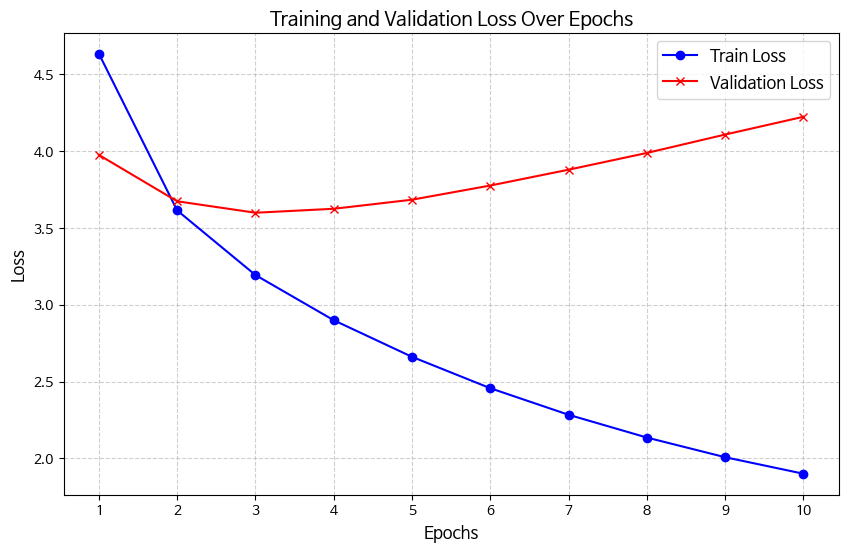

In [15]:
%time

model_save_path = os.path.join(base_path, "best_seq2seq_model.pt")

NUM_EPOCHS = 10
best_val_loss = float('inf')  # 훈련이 아니라 검증 기준 최저 손실 추적

# [추가] 기록용 리스트 선언
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # 1. 훈련 및 손실 기록
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # 2. 검증 및 손실 기록
    val_loss = eval_step(model, validation_loader, criterion)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_save_path)
        print(f"🔥 New Best Model Saved! (Val Loss: {best_val_loss:.4f})")
    print("-" * 50)

# --- [추가] 학습 완료 후 Loss 추이 그래프 출력 ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(val_losses, label='Validation Loss', color='red', marker='x')

plt.title('Training and Validation Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# X축 레이블을 1부터 정수로 표현하기 위한 셋팅
plt.xticks(range(NUM_EPOCHS), [f"{i+1}" for i in range(NUM_EPOCHS)])

plt.show()


📦 Successfully loaded the best model weights from '/home/jovyan/work/best_seq2seq_model.pt'

[Test Case 1]
Input          : 오바마는 대통령이다.
Mecab Split    : 오바마 는 대통령 이 다 .
Predicted (EN) : Obama's president for president. </s>


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


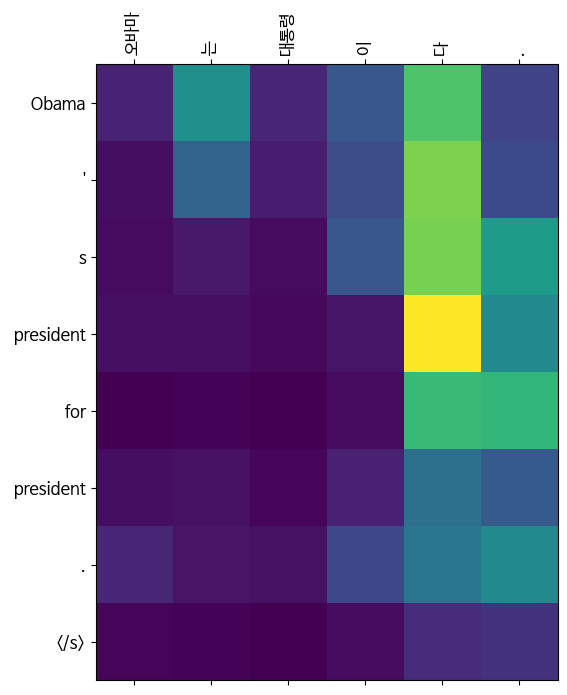

------------------------------------------------------------

[Test Case 2]
Input          : 시민들은 도시 속에 산다.
Mecab Split    : 시민 들 은 도시 속 에 산다 .
Predicted (EN) : The citizens are in the city. </s>


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


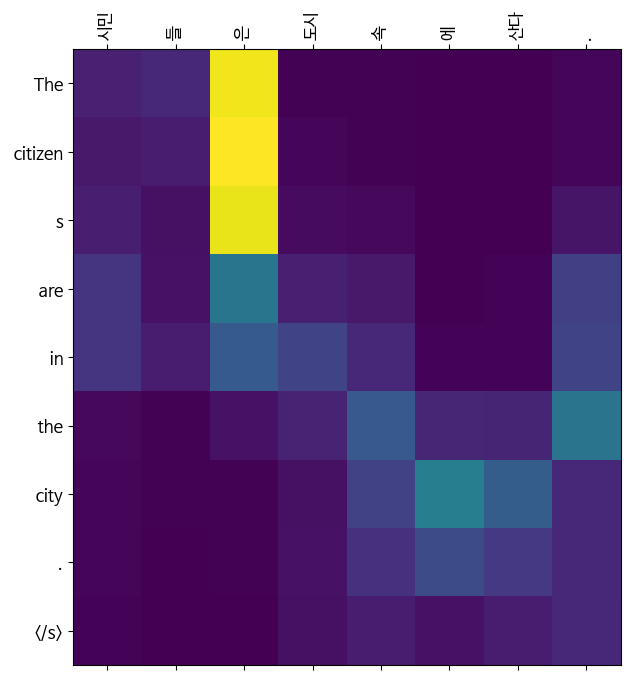

------------------------------------------------------------

[Test Case 3]
Input          : 커피는 필요 없다.
Mecab Split    : 커피 는 필요 없 다 .
Predicted (EN) : The needs are needed to be required to make a little more than a year. </s>


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


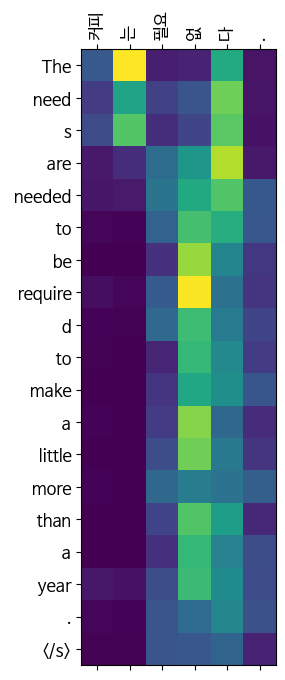

------------------------------------------------------------

[Test Case 4]
Input          : 일곱 명의 사망자가 발생했다.
Mecab Split    : 일곱 명 의 사망자 가 발생 했 다 .
Predicted (EN) : The death toll was killed in the death of death. </s>


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


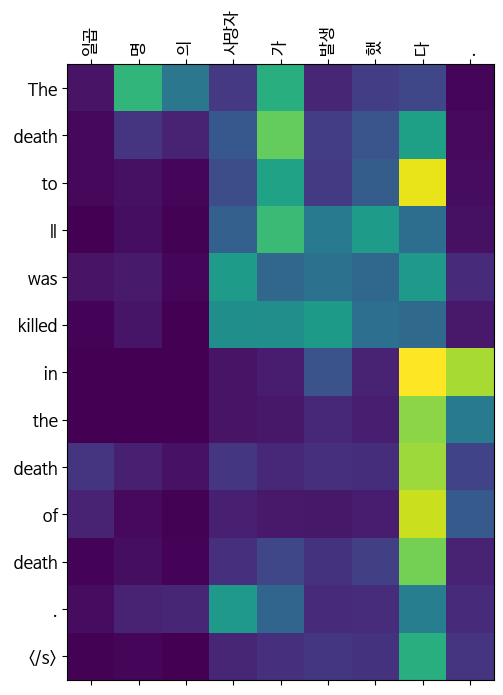

------------------------------------------------------------


In [25]:
# --- 3. 최종 평가 및 테스트 단계 (가장 잘 복습된 시점의 가중치 복원) ---
if os.path.exists(model_save_path):
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    print(f"📦 Successfully loaded the best model weights from '{model_save_path}'")
else:
    print(f"⚠️ Warning: '{model_save_path}' not found. Using current weights.")

input_list = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for i, sentence in enumerate(input_list, 1):
    print(f"\n[Test Case {i}]")
    
    # 이전에 수정했던 버그 픽스 버전의 translate 함수 호출
    translate(sentence, model, ko_vocab, en_spm, max_len=max_token_len)
    
    print("-" * 60)

In [39]:
max_len = 40
output_list = []
for i, sentence in enumerate(input_list, 1):
    translated_text, src_tokens, pred_tokens, attention = evaluate(
        sentence, model, ko_vocab, en_spm, max_len
    )
    
    print(f"K{i}: {sentence}\nE{i}: {translated_text}\n")
    


K1: 오바마는 대통령이다.
E1: Obama's president for president. </s>

K2: 시민들은 도시 속에 산다.
E2: The citizens are in the city. </s>

K3: 커피는 필요 없다.
E3: The needs are needed to be required to make a little more than a year. </s>

K4: 일곱 명의 사망자가 발생했다.
E4: The death toll was killed in the death of death. </s>



In [89]:
print("PAD:", en_spm.PieceToId('<pad>'), "expected: 0")
print("BOS:", en_spm.PieceToId('<s>'), "expected: 1")  # SPM은 보통 <s>를 씁니다
print("EOS:", en_spm.PieceToId('</s>'), "expected: 2") # SPM은 보통 </s>를 씁니다
print("UNK:", en_spm.PieceToId('<unk>'), "expected: 3")

PAD: 0 expected: 0
BOS: 1 expected: 1
EOS: 2 expected: 2
UNK: 3 expected: 3


노드 학습 내용
---

In [6]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))



데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng.zip', 'spa-eng']


In [8]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

In [9]:
# execute
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [37]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [10]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

I0000 00:00:1783908984.375728     312 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enabl

True

In [14]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [18]:
enc_token =  .encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
print("enc_token: ", enc_token)
enc_decoding = encoder_tokenizer.decode(enc_token)
print("dec_token: ", enc_decoding)

enc_token:  [1, 23, 7, 37, 397, 8, 2]
dec_token:  do you like fish ?


In [72]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

def train_step(model, data_loader, optimizer, criterion, epoch, best_loss, save_path="best_model.pt"):
    """
    에포크 단위로 학습을 진행하고, 최저 에포크 손실 달성 시 모델을 저장합니다.
    """
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 차원(seq_len, batch_size)에 맞게 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        
        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)
        
        # Loss 계산을 위한 차원 붕괴: (batch_size * trg_len, output_dim)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        # 그레디언트 폭발 방지 (Gradient Clipping)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    # 이번 에포크의 평균 손실 계산
    avg_epoch_loss = epoch_loss / len(data_loader)
    
    # [최적화 모델 저장 로직]
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        torch.save(model.state_dict(), save_path)
        print(f"\n🔥 [Epoch {epoch+1}] Best model saved with Loss: {best_loss:.4f}")

    return avg_epoch_loss, best_loss


def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

In [20]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [21]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [25]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [26]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [ ]:
# # train
%%time

# 초기화
NUM_EPOCHS = 10
best_loss = float('inf')  # 처음 비교를 위해 무한대로 설정

for epoch in range(NUM_EPOCHS):
    # train_step이 업데이트된 best_loss를 반환하므로 이를 계속 누적 관리합니다.
    epoch_loss, best_loss = train_step(
        model=model, 
        data_loader=train_dataloader, 
        optimizer=optimizer, 
        criterion=criterion, 
        epoch=epoch, 
        best_loss=best_loss,
        save_path="best_seq2seq_model.pt"
    )
    
    print(f"Epoch {epoch+1} Complete - Avg Loss: {epoch_loss:.4f}\n")

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')